In [6]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import utils
from morld.pi_morld import PIMORLD
from pymoo.indicators.hv import HV
from pymoo.operators.survival.rank_and_crowding.metrics import get_crowding_function
from moocore import hypervolume, hv_contributions
import mdp_utils

seed = 42
np.random.seed(seed)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
MAX_COUNT = 2
NUM_FEATURES = 3
NUM_VALS = 3
NUM_USER_STATES = NUM_VALS**NUM_FEATURES
NUM_CLUSTERS = 6
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CLUSTERS
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS
NUM_OBJECTIVES = 5

In [87]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\functions\\3'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

action_data = pd.read_csv(os.path.join(data_folder, 'action_data.csv'))
df = pd.read_csv(os.path.join(data_folder, 'samples.csv'))
initial_distribution = np.load(os.path.join(data_folder, 'initial_distribution.npy'))
cluster_col = 'cluster_all'

actions_clustered, _, cluster_cols = utils.cluster_actions(action_data, cluster_vars=['obs_diff', 'obs_time', 'obs_liked', 'obs_pu'], num_clusters=NUM_CLUSTERS)

action_categories = actions_clustered[cluster_col].values

reward_cols = ["obs_time", "obs_liked", "obs_pu", "r_expert", "r_diversity"]
obj_names = ["Time Required", "Fun", "Perceived Usefulness", "Expert Usefulness", "Diversity"]

obj_clusters = {r_col: cluster_col for r_col in reward_cols}
nO = len(obj_clusters)
P_comp = mdp_utils.compute_completion_probabilities_clustered(df, cluster_col, NUM_USER_STATES, NUM_ACTIONS, num_clusters=NUM_CLUSTERS, use_clusters=True)
R = mdp_utils.compute_rewards(df, P_comp, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, cluster_col)
P = mdp_utils.compute_transition_probabilities_clustered(df, NUM_USER_STATES, NUM_ACTIONS, cluster_col, num_clusters=NUM_CLUSTERS, use_clusters=True)

print("P shape:", P.shape)  # Should be (nU, nA, nU)
print("R shape:", R.shape)  # Should be (nU, nC, nA, nO)

P shape: (27, 6, 27)
R shape: (27, 729, 6, 5)


In [4]:
challenges_per_cluster = [[i for i in range(len(actions_clustered)) if actions_clustered[cluster_col].iloc[i] == cluster_id] for cluster_id in range(NUM_CLUSTERS)]
print("Challenges per cluster:", challenges_per_cluster)
challenge_info = actions_clustered.set_index('action_id').to_dict('records')
print("Challenge info example:", challenge_info[0])

Challenges per cluster: [[3, 6, 13, 14, 15, 18, 21, 27, 38, 41, 43, 46, 55, 58, 61, 63, 65, 67, 69, 80, 90, 94, 97], [16, 17, 42, 45, 51, 75, 84, 98, 102], [4, 9, 12, 22, 31, 32, 33, 34, 35, 53, 76, 79, 88, 89], [2, 10, 19, 24, 39, 40, 48, 49, 54, 56, 60, 66, 68, 73, 77, 83, 85, 86, 87, 91, 93, 100, 101, 103], [0, 1, 5, 7, 8, 26, 28, 37, 44, 47, 50, 52, 57, 62, 64, 71, 72, 78, 81, 96], [11, 20, 23, 25, 29, 30, 36, 59, 70, 74, 82, 92, 95, 99]]
Challenge info example: {'obs_diff': 0.2857142857142857, 'obs_time': 0.2733990147783251, 'obs_liked': 0.8128078817733989, 'obs_pu': 0.9359605911330048, 'category_id': 0, 'obs_diff_cluster': 5, 'obs_time_cluster': 1, 'obs_liked_cluster': 2, 'obs_pu_cluster': 2, 'cluster_all': 4}


In [88]:
env = mo_gym.make('user_env', num_actions=NUM_CLUSTERS, 
                 num_objectives = NUM_OBJECTIVES, 
                 challenge_info=challenge_info, 
                 challenges_per_cluster=challenges_per_cluster,
                 num_clusters=NUM_CLUSTERS,
                 transition_probs=P, 
                 completion_probs=P_comp,
                 reward_matrix=R, 
                 action_categories=np.array([i for i in range(NUM_CLUSTERS)]),
                 initial_distribution=initial_distribution,
                 MAX_COUNT=MAX_COUNT)

In [ ]:
pop_size = 16
weights_init = "combined"
scalarization = "linear"
max_eval_iters = 500
num_iterations = 5
gamma = 0.7
ref_point = np.array([0.5, 0.5, 0.5, 0.5, 0.5])  # Reference point for Chebyshev scalarization

model_name = f'pimorld_P={pop_size}_T={num_iterations}_nO={NUM_OBJECTIVES}_{scalarization}_{weights_init}'
filename = model_name
model_file = os.path.join(results_folder, model_name, filename)

# Initialize the PIMORLD algorithm
pi_morld = PIMORLD(env.unwrapped,
                   pop_size=pop_size, 
                   gamma=gamma,
                   max_eval_iters=max_eval_iters,
                   weights_init=weights_init,
                   scalarization=scalarization,
                   ref_point=ref_point)

Initial weights for agents:
[[0.         0.         0.         0.         1.        ]
 [0.         0.         0.         1.         0.        ]
 [0.         0.         0.49799681 0.         0.50200319]
 [0.         0.         1.         0.         0.        ]
 [0.         1.         0.         0.         0.        ]
 [0.30391237 0.         0.30386081 0.39222682 0.        ]
 [0.4969631  0.5030369  0.         0.         0.        ]
 [1.         0.         0.         0.         0.        ]
 [0.32092953 0.31184992 0.31833354 0.03734878 0.01153823]
 [0.20423268 0.19822942 0.43925151 0.01114814 0.14713825]
 [0.01562034 0.24150786 0.38394867 0.08579992 0.2731232 ]
 [0.0820249  0.04884865 0.16812119 0.48071285 0.22029241]
 [0.24026011 0.04306324 0.35401308 0.23635009 0.12631348]
 [0.2301249  0.25011621 0.04252682 0.09911094 0.37812114]
 [0.12700325 0.41308604 0.23150292 0.07774483 0.15066296]
 [0.25836269 0.13846587 0.12963756 0.35394962 0.11958425]]
Running policy iteration with weights: [0. 

In [18]:
pi_morld.train(num_iterations=num_iterations)

Iteration: 1
HV of Pareto Archive: 5.760405933902284
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Iteration: 2
HV of Pareto Archive: 5.768721274559844
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Iteration: 3
HV of Pareto Archive: 5.776538559607284
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Iteration: 4
HV of Pareto Archive: 5.777097169572706
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Iteration: 5
HV of Pareto Archive: 5.77737891852219


In [19]:
print("Hypervolume of Pareto Archive: ", pi_morld.get_hv())
print("Number of solutions in Pareto Archive: ", len(pi_morld.pareto_archive.evaluations))

Hypervolume of Pareto Archive:  5.779423110580698
Number of solutions in Pareto Archive:  79


### Run simulations

In [20]:
NUM_USERS = 500
NUM_TIMESTEPS = 28

In [ ]:
def retrieve_top_policies(pareto_archive, method, n=5):
    if method == "hv_contribution":
        ref_point_HV = np.min(pareto_archive.evaluations, axis=0) - 0.1  # Set reference point slightly worse than the worst evaluation in the archive
        metric = hv_contributions([eval for eval in pareto_archive.evaluations], ref_point_HV, maximise=True)
    elif method == "crowding":
        cd = get_crowding_function("cd")
        metric = cd.do(pareto_archive.evaluations)
    sorted_inds = np.argsort(metric)[::-1]
    top_n_individuals = np.array(pareto_archive.individuals)[sorted_inds][:n]
    top_n_evaluations = np.array(pareto_archive.evaluations)[sorted_inds][:n]
    policies = np.array([ind['policy'] for ind in top_n_individuals])
    weights = [ind['weights'] for ind in top_n_individuals]
    return policies, weights, top_n_evaluations


policies, weights, top_evaluations = retrieve_top_policies(pi_morld.pareto_archive, method="hv_contribution", n=5)
print("Top policies retrieved based on hypervolume contribution:")
for i, (policy, weight) in enumerate(zip(policies, weights)):
    print(f"Policy {i}: Weights: {weight}, Evaluation: {top_evaluations[i]}")

# best objective for each policy in top policies among the top policies
for i in range(NUM_OBJECTIVES):
    best_index = np.argmax([eval[i] for eval in top_evaluations])
    print(f"Best policy for objective {i} among top policies: Policy {best_index}")

Top policies retrieved based on hypervolume contribution:
Policy 0: Weights: [0.14534935 0.32830409 0.2649444  0.08897536 0.1724268 ], Evaluation: [1.16983675 1.38497319 1.72768604 0.55840086 2.25377717]
Policy 1: Weights: [0. 1. 0. 0. 0.], Evaluation: [1.02478826 1.50149878 1.62086901 0.52262271 2.11558231]
Policy 2: Weights: [0.12487394 0.17453285 0.55690975 0.01413429 0.12954917], Evaluation: [0.93776336 1.2427722  1.90752829 0.61030455 2.09263174]
Policy 3: Weights: [0. 0. 1. 0. 0.], Evaluation: [0.9483882  1.2402806  1.93248715 0.61792498 1.87791617]
Policy 4: Weights: [0.11596822 0.23340322 0.51719226 0.01312627 0.12031003], Evaluation: [0.97284876 1.25212734 1.91401384 0.61126983 2.01580074]
Best policy for objective 0 among top policies: Policy 0
Best policy for objective 1 among top policies: Policy 1
Best policy for objective 2 among top policies: Policy 3
Best policy for objective 3 among top policies: Policy 3
Best policy for objective 4 among top policies: Policy 0


In [89]:
save_path = results_folder + model_name + '/simulations/'
save_path = os.path.join(results_folder, model_name, 'simulations')
save = False

all_sim_results =[]
if os.path.exists(save_path):
    print(f"Directory {save_path} already exists. Simulation results will be saved there.")
    for i in range(len(policies)):
        sim_file = os.path.join(save_path, f'simulation_{i}.pkl')
        if os.path.exists(sim_file):
            print(f"Simulation file {sim_file} already exists. Loading results.")
            sim_results = pd.read_pickle(sim_file)
            all_sim_results.append(sim_results)
        else:
            print(f"Simulation file {sim_file} does not exist. Please run the simulations to generate the results.")

else:
    if save:
        os.makedirs(save_path)
    for i, policy in enumerate(policies):
        print(f"Simulating Policy {i}:")
        simulation_results = sim_utils.simulate(env, NUM_USERS, policy=policy, policy_name=f"Policy {i}", max_count=MAX_COUNT)
        all_sim_results.append(simulation_results)
        if save:
            save_file = f'simulation_{i}.pkl'
            save_to = os.path.join(save_path, save_file)
            simulation_results.to_pickle(save_to)

Simulating Policy 0:
Simulating Policy 1:
Simulating Policy 2:
Simulating Policy 3:
Simulating Policy 4:


In [90]:
random_sim_file = f'random/simulation_random_n={NUM_USERS}_nO={NUM_OBJECTIVES}.pkl'
random_sim_path = os.path.join(results_folder, random_sim_file)

if os.path.exists(random_sim_path):
    simulation_random = pd.read_pickle(random_sim_path)
else:
    simulation_random = sim_utils.simulate(env, NUM_USERS, max_count=MAX_COUNT)
    simulation_random.to_pickle(random_sim_path)


#### Simulate choices between multiple optimal policies

In [91]:
choice_policies = []
multi_policy_simulation_results_fun = sim_utils.simulate_multiple_policies(env, NUM_USERS, policies, top_evaluations, selection='user_choice_most_fun', max_count=MAX_COUNT)
all_sim_results.append(multi_policy_simulation_results_fun)
choice_policies.append(multi_policy_simulation_results_fun)

multi_policy_simulation_results_time = sim_utils.simulate_multiple_policies(env, NUM_USERS, policies, top_evaluations, selection='user_choice_least_time', max_count=MAX_COUNT)
all_sim_results.append(multi_policy_simulation_results_time)
choice_policies.append(multi_policy_simulation_results_time)

multi_policy_simulation_results_random = sim_utils.simulate_multiple_policies(env, NUM_USERS, policies, top_evaluations, selection='user_choice_random', max_count=MAX_COUNT)
all_sim_results.append(multi_policy_simulation_results_random)
choice_policies.append(multi_policy_simulation_results_random)

sim_utils.interactive_plot_objective(choice_policies + [simulation_random], obj_names)

interactive(children=(Dropdown(description='Objective:', options=(('Time Required', 0), ('Fun', 1), ('Perceive…

### Analyze and visualize simulations

In [92]:
all_policies = all_sim_results + [simulation_random]
policy_names = [f"Policy {i}" for i in range(len(all_sim_results))] + ["Random Policy"]

for j in range(NUM_OBJECTIVES):
    print(f"\n--- {obj_names[j]} ---")
    for idx, sim_res in enumerate(all_policies):
        raw_rewards = np.stack(sim_res['rewards'])
        rewards = raw_rewards.reshape(NUM_USERS, NUM_TIMESTEPS, NUM_OBJECTIVES)
        
        user_means = np.mean(rewards[:, :, j], axis=1) 
        grand_mean = np.mean(user_means)
        n = len(user_means)
        sem = stats.sem(user_means)
        ci = stats.t.interval(0.95, df=n-1, loc=grand_mean, scale=sem)
        
        print(f"{policy_names[idx]:<15} | Mean: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")


--- Time Required ---
Policy 0        | Mean: 0.2681 | 95% CI: (0.2628, 0.2735)
Policy 1        | Mean: 0.2472 | 95% CI: (0.2459, 0.2484)
Policy 2        | Mean: 0.3684 | 95% CI: (0.3577, 0.3791)
Policy 3        | Mean: 0.4189 | 95% CI: (0.4151, 0.4227)
Policy 4        | Mean: 0.4038 | 95% CI: (0.3929, 0.4147)
Policy 5        | Mean: 0.2486 | 95% CI: (0.2473, 0.2499)
Policy 6        | Mean: 0.2695 | 95% CI: (0.2639, 0.2751)
Policy 7        | Mean: 0.4061 | 95% CI: (0.4002, 0.4121)
Random Policy   | Mean: 0.2515 | 95% CI: (0.2478, 0.2552)

--- Fun ---
Policy 0        | Mean: 0.4636 | 95% CI: (0.4615, 0.4657)
Policy 1        | Mean: 0.5112 | 95% CI: (0.5095, 0.5129)
Policy 2        | Mean: 0.4409 | 95% CI: (0.4391, 0.4428)
Policy 3        | Mean: 0.4399 | 95% CI: (0.4382, 0.4415)
Policy 4        | Mean: 0.4419 | 95% CI: (0.4402, 0.4435)
Policy 5        | Mean: 0.5125 | 95% CI: (0.5108, 0.5142)
Policy 6        | Mean: 0.4641 | 95% CI: (0.4619, 0.4663)
Policy 7        | Mean: 0.4591 | 95%

In [93]:
sim_utils.interactive_plot_objective(all_policies, obj_names)

interactive(children=(Dropdown(description='Objective:', options=(('Time Required', 0), ('Fun', 1), ('Perceive…

#### Inspect adherence

In [94]:
for idx, sim_res in enumerate(all_policies):
    num_completed = np.stack(sim_res['num_completed']).reshape(NUM_USERS, NUM_TIMESTEPS)[:, -1]
    adherence_per_user = num_completed / NUM_TIMESTEPS
    grand_mean = np.mean(adherence_per_user)
    n = NUM_USERS
    sem = stats.sem(adherence_per_user)
    ci = stats.t.interval(0.95, df=n-1, loc=grand_mean, scale=sem)
    print(f"{policy_names[idx]:<15} | Adherence: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

Policy 0        | Adherence: 0.7514 | 95% CI: (0.7437, 0.7592)
Policy 1        | Adherence: 0.6969 | 95% CI: (0.6891, 0.7047)
Policy 2        | Adherence: 0.7803 | 95% CI: (0.7732, 0.7873)
Policy 3        | Adherence: 0.8099 | 95% CI: (0.8026, 0.8173)
Policy 4        | Adherence: 0.7822 | 95% CI: (0.7750, 0.7894)
Policy 5        | Adherence: 0.8014 | 95% CI: (0.7945, 0.8082)
Policy 6        | Adherence: 0.8677 | 95% CI: (0.8616, 0.8738)
Policy 7        | Adherence: 0.8892 | 95% CI: (0.8836, 0.8948)
Random Policy   | Adherence: 0.6964 | 95% CI: (0.6889, 0.7040)


<Axes: xlabel='Timesteps', ylabel='Mean num_completed'>

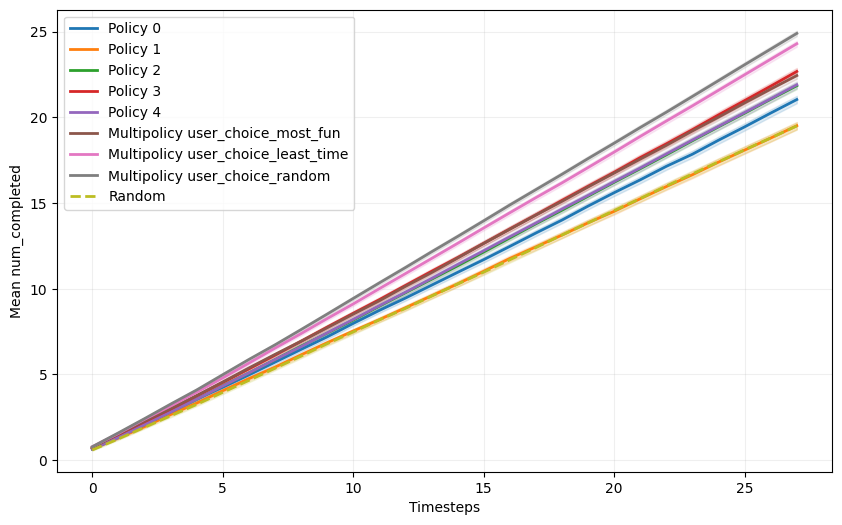

In [95]:
sim_utils.plot_simulation(all_policies, 'num_completed')

#### Inspect number of users per state

In [96]:
features = ["Tiredness", "Time available", "Perceived usefulness"]
for idx, sim_res in enumerate(all_policies):
    states = np.stack(sim_res['state']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)[:, -1, 0:3]
    for i in range(NUM_FEATURES):
        feature_values = states[:, i]
        count_per_value = np.bincount(feature_values.astype(int))
        print(f"Policy {policy_names[idx]} - Feature {features[i]}: Value distribution: {count_per_value}")

Policy Policy 0 - Feature Tiredness: Value distribution: [160 309  31]
Policy Policy 0 - Feature Time available: Value distribution: [150 325  25]
Policy Policy 0 - Feature Perceived usefulness: Value distribution: [ 17  17 466]
Policy Policy 1 - Feature Tiredness: Value distribution: [127 330  43]
Policy Policy 1 - Feature Time available: Value distribution: [142 336  22]
Policy Policy 1 - Feature Perceived usefulness: Value distribution: [ 12  18 470]
Policy Policy 2 - Feature Tiredness: Value distribution: [134 330  36]
Policy Policy 2 - Feature Time available: Value distribution: [167 314  19]
Policy Policy 2 - Feature Perceived usefulness: Value distribution: [ 14   8 478]
Policy Policy 3 - Feature Tiredness: Value distribution: [129 335  36]
Policy Policy 3 - Feature Time available: Value distribution: [168 307  25]
Policy Policy 3 - Feature Perceived usefulness: Value distribution: [ 11  12 477]
Policy Policy 4 - Feature Tiredness: Value distribution: [145 320  35]
Policy Policy

#### Inspect diversity

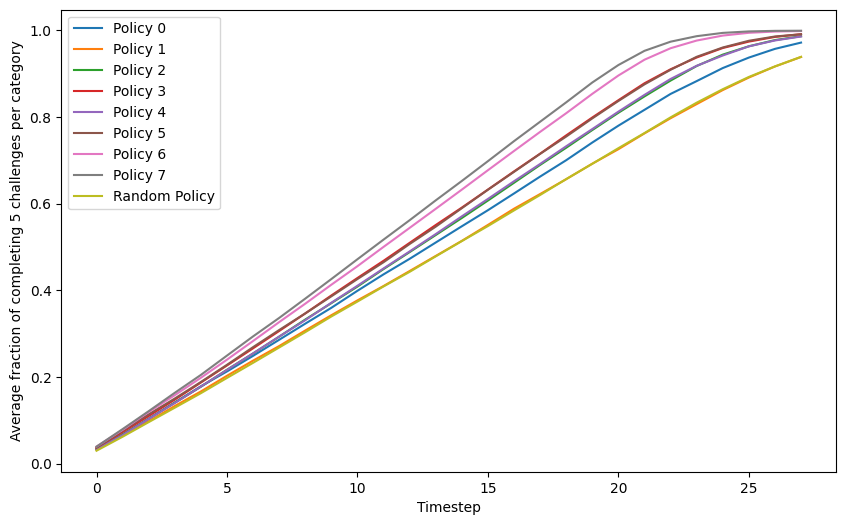

In [97]:
plt.figure(figsize=(10, 6))
for idx, sim_res in enumerate(all_policies):
    counts_per_category = np.stack(sim_res['counts_per_category']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)
    max_count_per_category = 5
    counts_per_category = np.clip(counts_per_category, 0, max_count_per_category)
    counts = counts_per_category.sum(axis=2)
    fraction_completed = counts / (max_count_per_category*4)
    mean_fraction_completed = fraction_completed.mean(axis=0)
    plt.plot(mean_fraction_completed, label=policy_names[idx])
plt.xlabel('Timestep')
plt.ylabel(f'Average fraction of completing {max_count_per_category} challenges per category')
plt.legend()
